In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor


Torch version: 2.10.0+cu128
Pandas version: 3.0.1
All imports successful.


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

model_id = "microsoft/Florence-2-base-ft"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    trust_remote_code=True
).to(device)

processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Model and processor loaded.")
print("Device:", device)
print("Torch dtype:", torch_dtype)

Model and processor loaded.
Device: cuda
Torch dtype: torch.float16


Image size: (937, 1280)


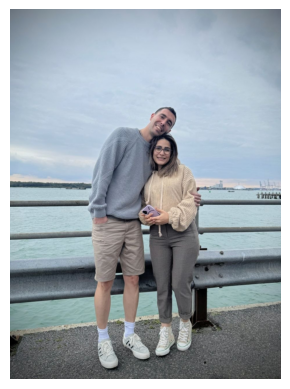

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../data/raw/sample.jpg"
image = Image.open(image_path).convert("RGB")

print("Image size:", image.size)

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project root added to Python path:", project_root)

Project root added to Python path: /home/aaa79306/Farzad/Projects/SIC


In [ ]:
from src.captioning import load_florence_model, generate_caption

model, processor, device, torch_dtype = load_florence_model()

result = generate_caption(
    image_path="../data/raw/sample.png",
    model=model,
    processor=processor,
    device=device,
    torch_dtype=torch_dtype,
)

print(result["caption"])

A man is standing on a tiled floor. He is wearing a blue shirt, a brown jacket and blue jeans. He has black shoes on his feet. There is a brown wall behind the man. 


In [ ]:
from src.feature_extraction import extract_features_from_caption

features = extract_features_from_caption(result["caption"])
#features

full_result = {
    "image_path": result["image_path"],
    "caption": result["caption"],
    "features": features
}

full_result


{'image_path': '../data/raw/sample.png',
 'caption': 'A man is standing on a tiled floor. He is wearing a blue shirt, a brown jacket and blue jeans. He has black shoes on his feet. There is a brown wall behind the man. ',
 'features': {'colors': ['black', 'blue', 'brown'],
  'garments': ['shirt', 'jacket', 'jeans', 'shoes'],
  'upper_wear': ['shirt', 'jacket'],
  'lower_wear': ['jeans'],
  'footwear': ['shoes'],
  'accessories': [],
  'materials': [],
  'style_words': [],
  'item_color_pairs': [{'item': 'shoes', 'color': 'black'},
   {'item': 'shirt', 'color': 'blue'},
   {'item': 'jeans', 'color': 'blue'},
   {'item': 'jacket', 'color': 'brown'}]}}

In [ ]:
import json

output_path = "../data/outputs/full_result.json"

with open(output_path, "w") as f:
    json.dump(full_result, f, indent=2)

print("Saved to:", output_path)

Saved to: ../data/outputs/full_result.json


In [ ]:
from src.captioning import load_florence_model, generate_caption

model, processor, device, torch_dtype = load_florence_model()

result = generate_caption(
    image_path="../data/raw/sample.jpg",
    model=model,
    processor=processor,
    device=device,
    torch_dtype=torch_dtype,
    task_prompt="<MORE_DETAILED_CAPTION>",
    user_prompt="Focus on outfit items, colors, and style. Ignore the background."
)

print("Final prompt:", result["final_prompt"])
print("Caption:", result["caption"])

TypeError: generate_caption() got an unexpected keyword argument 'task_prompt'